In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q grad-cam datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import models
from torchvision import transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from datasets import load_dataset

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [5]:
dataset = load_dataset(
    "electricsheepafrica/Africa-Blood-Cell-Images-and-EHR-for-Cancer-Detection"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.24k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/3.69k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/129M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [6]:
split_dataset = dataset["train"].train_test_split(
    test_size=0.2,
    seed=42
)

train_data = split_dataset["train"]
test_data = split_dataset["test"]

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
class BloodDataset(Dataset):

    def __init__(self, hf_dataset, transform=None):

        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        image = item["image"]

        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
train_dataset = BloodDataset(
    train_data,
    transform
)

test_dataset = BloodDataset(
    test_data,
    transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
num_classes = 5

model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(
        model.fc.in_features,
        num_classes
    )
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.8MB/s]


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [12]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": []
}

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_acc = correct / total

    history["train_loss"].append(
        epoch_loss
    )

    history["train_acc"].append(
        epoch_acc
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss={epoch_loss:.4f} "
        f"Acc={epoch_acc:.4f}"
    )

Epoch [1/10] Loss=0.1332 Acc=0.9577
Epoch [2/10] Loss=0.0120 Acc=0.9980
Epoch [3/10] Loss=0.0094 Acc=0.9982
Epoch [4/10] Loss=0.0102 Acc=0.9975
Epoch [5/10] Loss=0.0066 Acc=0.9985
Epoch [6/10] Loss=0.0115 Acc=0.9968
Epoch [7/10] Loss=0.0049 Acc=0.9988
Epoch [8/10] Loss=0.0014 Acc=1.0000
Epoch [9/10] Loss=0.0006 Acc=1.0000
Epoch [10/10] Loss=0.0004 Acc=1.0000


In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [14]:
def enable_dropout(model):

    for m in model.modules():

        if isinstance(
            m,
            nn.Dropout
        ):
            m.train()

In [15]:
class_names = [
        'basophil',
        'erythroblast',
        'monocyte',
        'myeloblast',
        'seg_neutrophil'
]

In [21]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/trushworthy ai/best_model.pth"
)

In [22]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
target_layers = [
    model.layer4[-1]
]

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("="*50)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*50)

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)

                precision    recall  f1-score   support

      basophil     1.0000    1.0000    1.0000       196
  erythroblast     1.0000    1.0000    1.0000       197
      monocyte     1.0000    1.0000    1.0000       200
    myeloblast     1.0000    1.0000    1.0000       208
seg_neutrophil     1.0000    1.0000    1.0000       199

      accuracy                         1.0000      1000
     macro avg     1.0000    1.0000    1.0000      1000
  weighted avg     1.0000    1.0000    1.0000      1000



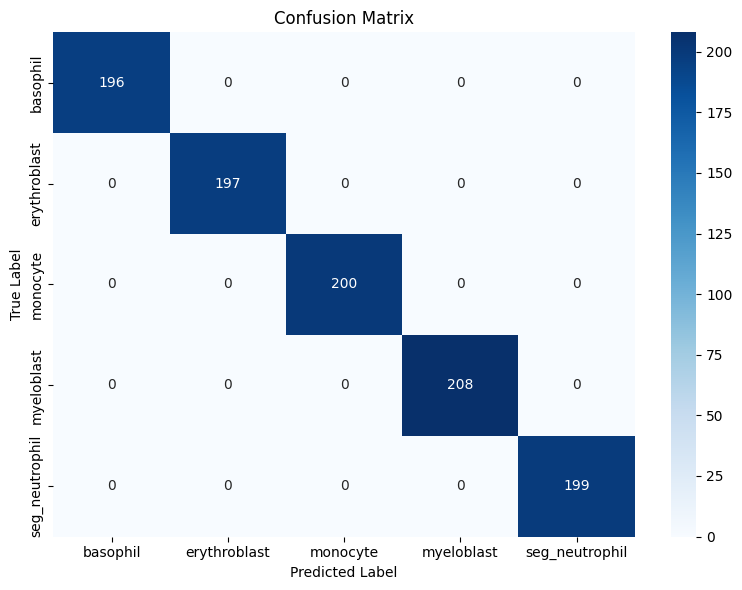

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
import os
os.makedirs("figs", exist_ok=True)
plt.savefig("figs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

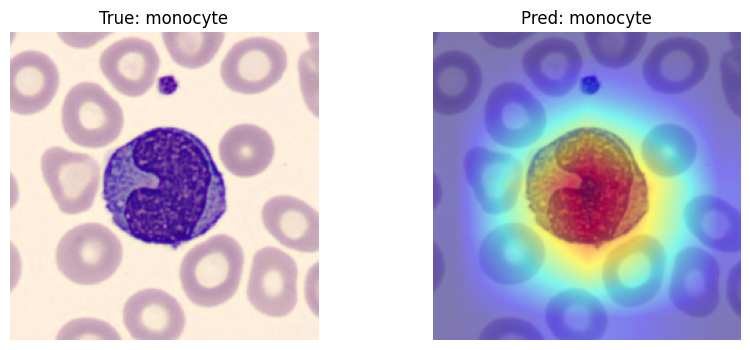

Confidence: 1.0000


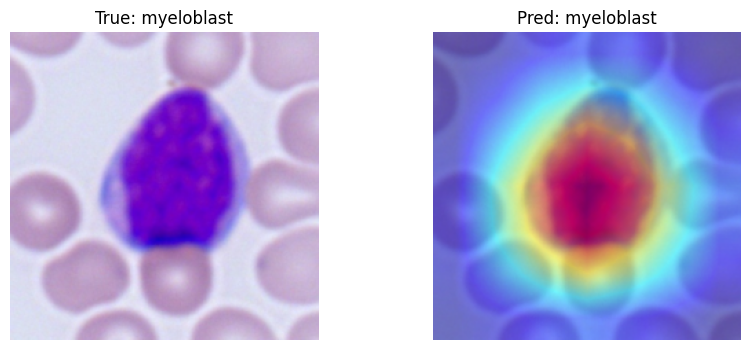

Confidence: 1.0000


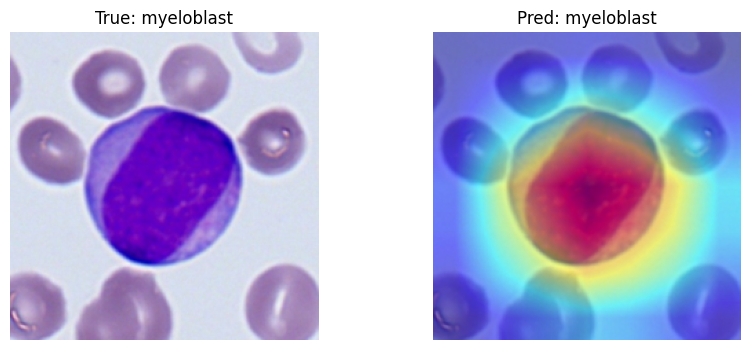

Confidence: 1.0000


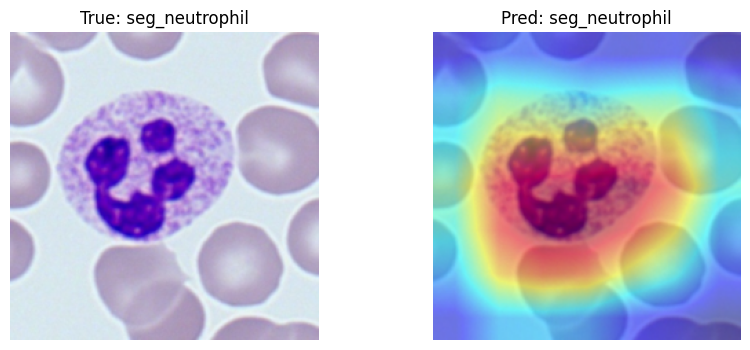

Confidence: 1.0000


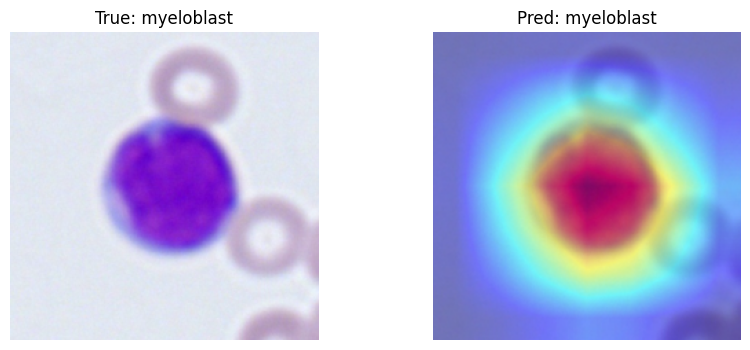

Confidence: 0.9999


In [28]:
import torch.nn.functional as F

model.eval()
target_layers = [
    model.layer4[-1]
]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)


for i in range(5):

    image, label = test_dataset[i]

    input_tensor = (
        image.unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

        probs = F.softmax(
            output,
            dim=1
        )

        pred = probs.argmax(1).item()

        confidence = probs.max().item()

    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    rgb_img = image.permute(
        1,2,0
    ).cpu().numpy()

    rgb_img = (
        rgb_img-rgb_img.min()
    ) / (
        rgb_img.max()-rgb_img.min()
    )

    cam_image = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title(
        f"True: {class_names[label]}"
    )
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cam_image)
    plt.title(
        f"Pred: {class_names[pred]}"
    )
    plt.axis("off")

    plt.show()

    print(
        f"Confidence: {confidence:.4f}"
    )

In [29]:
import torch.nn.functional as F
import numpy as np

def mc_dropout_predict(
    model,
    image,
    T=30
):

    enable_dropout(model)

    predictions = []

    with torch.no_grad():

        for _ in range(T):

            output = model(image)

            probs = F.softmax(
                output,
                dim=1
            )

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(
        predictions
    )

    mean_probs = predictions.mean(
        axis=0
    )

    std_probs = predictions.std(
        axis=0
    )

    return mean_probs, std_probs

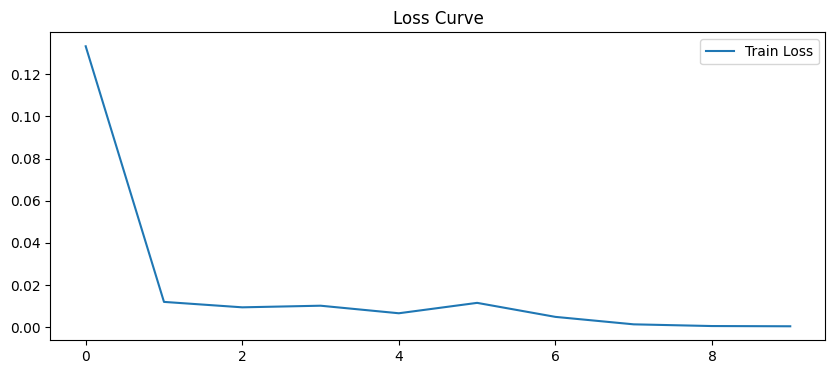

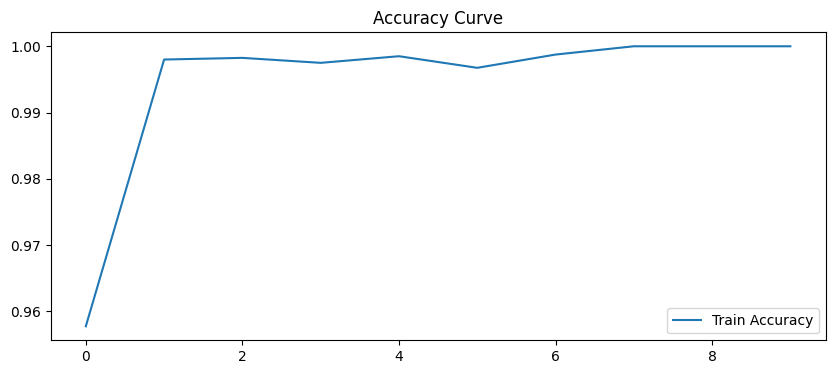

In [30]:
plt.figure(figsize=(10,4))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(10,4))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [31]:
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

mean_probs, std_probs = mc_dropout_predict(
    model,
    input_tensor,
    T=30
)

print("Mean probabilities:")
print(mean_probs)

print()

print("Uncertainty:")
print(std_probs)

print()

print(
    "Max uncertainty:",
    std_probs.max()
)
uncertainties = []
confidences = []

for idx in range(len(test_dataset)):

    image, label = test_dataset[idx]

    input_tensor = (
        image.unsqueeze(0)
        .to(device)
    )

    mean_probs, std_probs = mc_dropout_predict(
        model,
        input_tensor,
        T=30
    )

    confidences.append(
        mean_probs.max()
    )

    uncertainties.append(
        std_probs.max()
    )

Mean probabilities:
[[1.1201644e-05 2.3962371e-06 9.9998212e-01 1.9870790e-06 2.2215277e-06]]

Uncertainty:
[[9.0845542e-06 2.5958409e-06 1.2820847e-05 1.8024891e-06 2.1541048e-06]]

Max uncertainty: 1.2820847e-05


In [32]:
print(
    "Mean Uncertainty:",
    np.mean(uncertainties)
)

print(
    "Std Uncertainty:",
    np.std(uncertainties)
)

print(
    "Max Uncertainty:",
    np.max(uncertainties)
)

print(
    "Min Uncertainty:",
    np.min(uncertainties)
)

Mean Uncertainty: 0.0002033065
Std Uncertainty: 0.0016742207
Max Uncertainty: 0.042019587
Min Uncertainty: 1.36788e-07


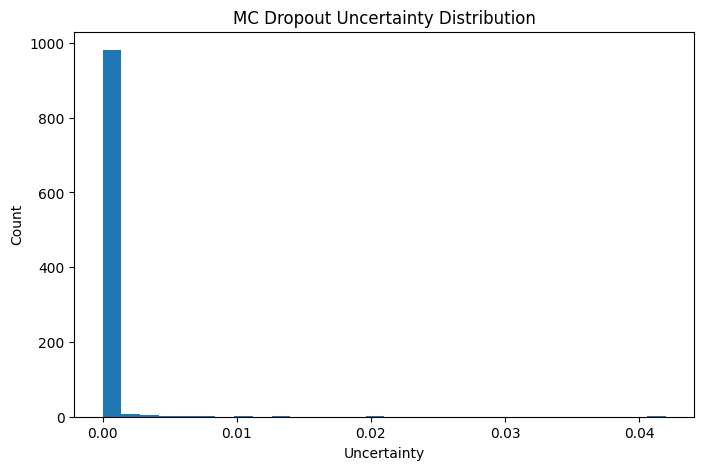

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    uncertainties,
    bins=30
)

plt.xlabel(
    "Uncertainty"
)

plt.ylabel(
    "Count"
)

plt.title(
    "MC Dropout Uncertainty Distribution"
)

plt.show()

In [34]:
model.eval()

confidences = []
correctness = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = F.softmax(
            outputs,
            dim=1
        )

        conf, pred = probs.max(1)

        confidences.extend(
            conf.cpu().numpy()
        )

        correctness.extend(
            (
                pred.cpu()
                ==
                labels
            ).cpu().numpy()
        )

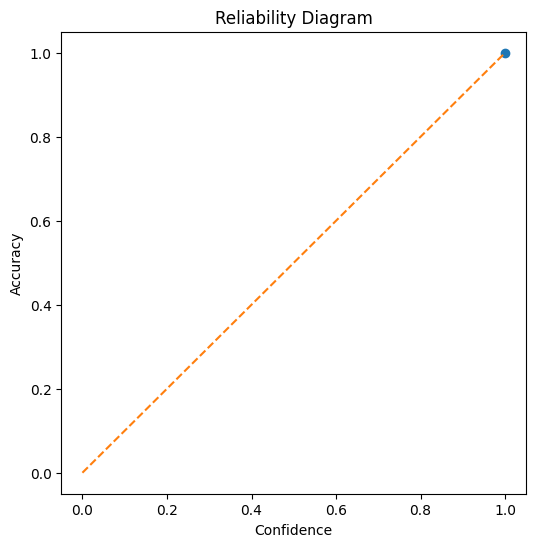

In [46]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    correctness,
    confidences,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("Confidence")

plt.ylabel("Accuracy")

plt.title(
    "Reliability Diagram"
)
plt.savefig("figs/reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
def compute_ece(
    confidences,
    correctness,
    n_bins=10
):

    bins = np.linspace(
        0,
        1,
        n_bins+1
    )

    ece = 0

    for i in range(n_bins):

        mask = (
            (np.array(confidences) > bins[i])
            &
            (np.array(confidences) <= bins[i+1])
        )

        if mask.sum() == 0:
            continue

        acc = np.mean(
            np.array(correctness)[mask]
        )

        conf = np.mean(
            np.array(confidences)[mask]
        )

        ece += (
            mask.mean()
            *
            abs(acc-conf)
        )

    return ece

In [37]:
ece = compute_ece(
    confidences,
    correctness
)

print(
    f"ECE = {ece:.4f}"
)

ECE = 0.0003


In [38]:
def fgsm_attack(
    image,
    epsilon,
    data_grad
):

    sign_data_grad = data_grad.sign()

    perturbed_image = (
        image
        +
        epsilon * sign_data_grad
    )


    return perturbed_image

In [39]:
epsilons = [
    0,
    0.005,
    0.01,
    0.02,
    0.05
]

fgsm_accs = []

In [40]:
for epsilon in epsilons:

    correct = 0

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        model.zero_grad()

        loss.backward()

        data_grad = images.grad.data

        perturbed_data = fgsm_attack(
            images,
            epsilon,
            data_grad
        )

        outputs = model(
            perturbed_data
        )

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

    acc = correct / len(test_dataset)

    fgsm_accs.append(acc)

    print(
        f"Epsilon={epsilon} "
        f"Accuracy={acc:.4f}"
    )

Epsilon=0 Accuracy=1.0000
Epsilon=0.005 Accuracy=0.9700
Epsilon=0.01 Accuracy=0.9060
Epsilon=0.02 Accuracy=0.7920
Epsilon=0.05 Accuracy=0.6750


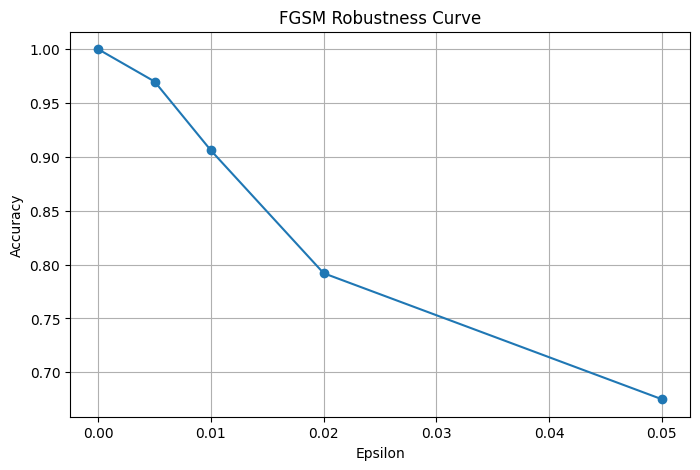

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    epsilons,
    fgsm_accs,
    marker="o"
)

plt.xlabel(
    "Epsilon"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "FGSM Robustness Curve"
)

plt.grid()

plt.show()

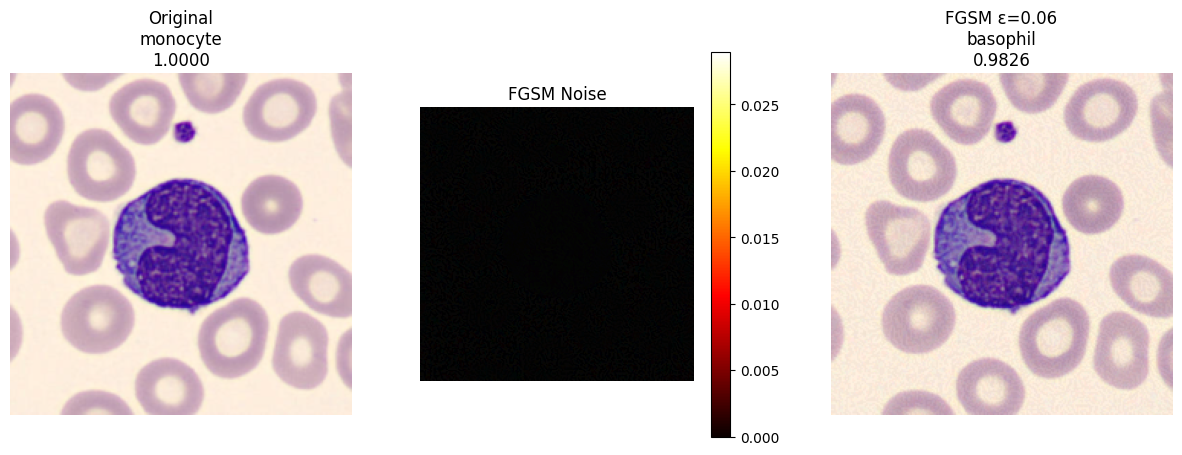

True Label : monocyte
Before FGSM: monocyte 0.9999897480010986
After FGSM : basophil 0.9826448559761047


In [42]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

epsilon = 0.06

image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)
target = torch.tensor([label]).to(device)

input_tensor.requires_grad = True

output = model(input_tensor)
loss = criterion(output, target)

model.zero_grad()
loss.backward()

data_grad = input_tensor.grad.data

perturbed = fgsm_attack(
    input_tensor,
    epsilon,
    data_grad
)

with torch.no_grad():

    output_before = model(input_tensor)
    prob_before = F.softmax(output_before, dim=1)

    pred_before = prob_before.argmax(1).item()
    conf_before = prob_before.max().item()

    output_after = model(perturbed)
    prob_after = F.softmax(output_after, dim=1)

    pred_after = prob_after.argmax(1).item()
    conf_after = prob_after.max().item()

orig = image.permute(1,2,0).cpu().numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())

adv = perturbed.squeeze().detach().cpu().permute(1,2,0).numpy()
adv = (adv - adv.min()) / (adv.max() - adv.min())

noise = adv - orig

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(orig)
plt.title(
    f"Original\n{class_names[pred_before]}\n{conf_before:.4f}"
)
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(
    np.abs(noise),
    cmap="hot"
)
plt.colorbar()
plt.title("FGSM Noise")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(adv)
plt.title(
    f"FGSM ε={epsilon}\n{class_names[pred_after]}\n{conf_after:.4f}"
)
plt.axis("off")

plt.show()

print("True Label :", class_names[label])
print("Before FGSM:", class_names[pred_before], conf_before)
print("After FGSM :", class_names[pred_after], conf_after)

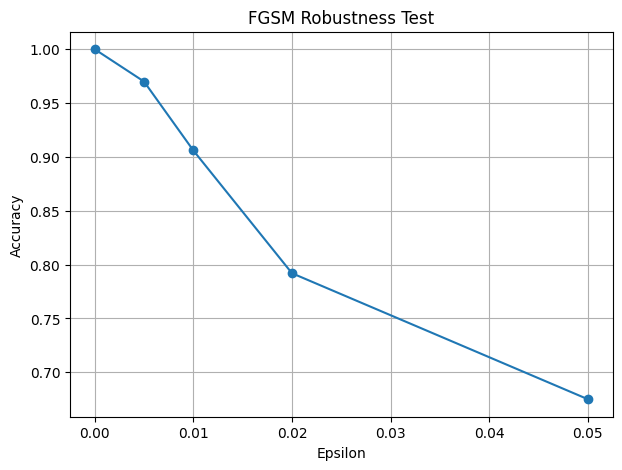

In [43]:
plt.figure(figsize=(7,5))

plt.plot(
    epsilons,
    fgsm_accs,
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM Robustness Test")

plt.grid(True)
plt.show()

In [44]:
print(len(test_dataset), len(confidences), class_names)

1000 1000 ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


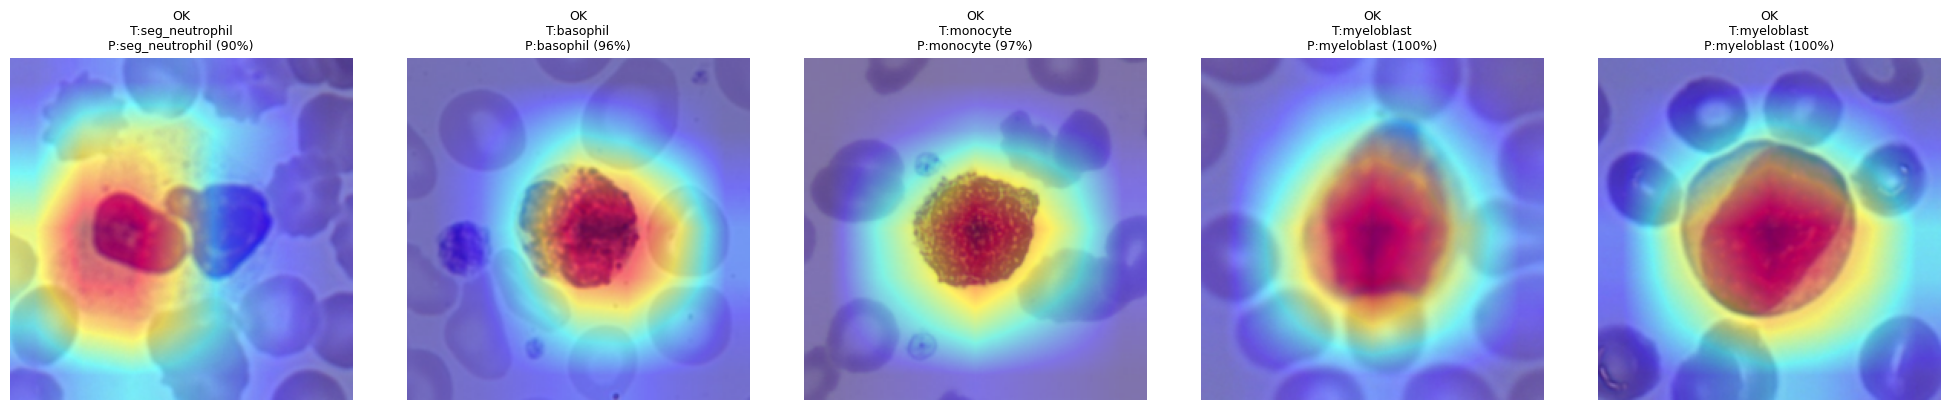

Tổng ca sai trên test: 0 / 1000


In [49]:
import os, numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

os.makedirs("figs", exist_ok=True)
model.eval()
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
def denorm(t):
    img = (t.cpu()*std + mean).permute(1,2,0).numpy()
    return np.clip(img, 0, 1)

records = []
for idx in range(len(test_dataset)):
    image, label = test_dataset[idx]
    inp = image.unsqueeze(0).to(device)
    with torch.no_grad():
        p = F.softmax(model(inp), dim=1)[0]
    conf, pred = p.max(0)
    records.append((idx, int(label), int(pred), float(conf)))

wrong   = [r for r in records if r[1] != r[2]]
correct = sorted([r for r in records if r[1] == r[2]], key=lambda r: r[3])
myelo_i = class_names.index('myeloblast')
myelo   = [r for r in records if r[2] == myelo_i and r[1] == r[2]][:2]

picks = (wrong[:3] if wrong else correct[:3]) + correct[:2] + myelo
seen = set(); picks = [r for r in picks if not (r[0] in seen or seen.add(r[0]))][:6]

n = len(picks)
plt.figure(figsize=(4*n, 4))
for j,(idx,label,pred,conf) in enumerate(picks):
    image,_ = test_dataset[idx]
    inp  = image.unsqueeze(0).to(device)
    gcam = cam(input_tensor=inp)[0]
    overlay = show_cam_on_image(denorm(image), gcam, use_rgb=True)
    tag = "OK" if label==pred else "WRONG"
    plt.subplot(1, n, j+1); plt.imshow(overlay); plt.axis("off")
    plt.title(f"{tag}\nT:{class_names[label]}\nP:{class_names[pred]} ({conf*100:.0f}%)", fontsize=9)
plt.tight_layout()
plt.savefig("figs/gradcam_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tổng ca sai trên test: {len(wrong)} / {len(records)}")

In [50]:
import numpy as np, torch, torch.nn.functional as F
import torchvision.transforms.functional as TF

mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(device)
std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(device)
to_pixel = lambda x: (x*std + mean).clamp(0,1)     # normalized -> [0,1]
to_norm  = lambda x: (x - mean) / std

def corrupt(x_norm, kind, sev):
    x = to_pixel(x_norm)
    if kind == "gauss_noise":
        x = (x + torch.randn_like(x)*sev).clamp(0,1)
    elif kind == "blur":
        k = int(sev); k = k+1 if k % 2 == 0 else k
        x = TF.gaussian_blur(x, kernel_size=max(3,k))
    elif kind == "brightness":
        x = (x*sev).clamp(0,1)
    elif kind == "jpeg":
        from torchvision.io import encode_jpeg, decode_jpeg
        outs = []
        for img in x:
            enc = encode_jpeg((img*255).byte().cpu(), quality=int(sev))
            outs.append(decode_jpeg(enc).float()/255.)
        x = torch.stack(outs).to(x.device)
    return to_norm(x)

@torch.no_grad()
def eval_corrupt(kind, sev):
    model.eval(); correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(corrupt(images, kind, sev)).argmax(1)
        correct += (preds == labels).sum().item(); total += labels.size(0)
    return correct/total

print(f"Clean: {eval_corrupt('brightness',1.0):.4f}")
plan = {
    "gauss_noise": [0.02, 0.05, 0.10, 0.20],
    "blur":        [3, 5, 9, 13],
    "brightness":  [0.7, 0.5, 1.3, 1.6],
    "jpeg":        [80, 50, 30, 15],
}
for kind, sevs in plan.items():
    for s in sevs:
        print(f"{kind:12s} sev={str(s):<5} acc={eval_corrupt(kind, s):.4f}")

Clean: 1.0000
gauss_noise  sev=0.02  acc=0.9990
gauss_noise  sev=0.05  acc=0.9980
gauss_noise  sev=0.1   acc=0.9680
gauss_noise  sev=0.2   acc=0.2440
blur         sev=3     acc=1.0000
blur         sev=5     acc=0.9980
blur         sev=9     acc=0.9810
blur         sev=13    acc=0.9450
brightness   sev=0.7   acc=0.9980
brightness   sev=0.5   acc=0.7800
brightness   sev=1.3   acc=0.9050
brightness   sev=1.6   acc=0.7400
jpeg         sev=80    acc=1.0000
jpeg         sev=50    acc=0.9960
jpeg         sev=30    acc=0.9990
jpeg         sev=15    acc=0.9940


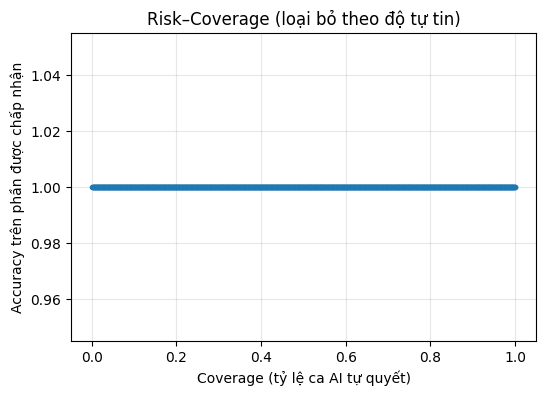

Ngưỡng | Coverage (tự quyết) | Accuracy trên phần chấp nhận
conf>=0.75|   1.000            |   1.0000
conf>=0.9 |   1.000            |   1.0000
conf>=0.95|   0.999            |   1.0000


In [51]:
import numpy as np, matplotlib.pyplot as plt, os
os.makedirs("figs", exist_ok=True)

conf = np.asarray(confidences)
corr = np.asarray(correctness).astype(float)

order = np.argsort(-conf)
corr_sorted = corr[order]
coverage = np.arange(1, len(corr)+1) / len(corr)
selective_acc = np.cumsum(corr_sorted) / np.arange(1, len(corr)+1)

plt.figure(figsize=(6,4))
plt.plot(coverage, selective_acc, marker='.')
plt.xlabel("Coverage (tỷ lệ ca AI tự quyết)")
plt.ylabel("Accuracy trên phần được chấp nhận")
plt.title("Risk–Coverage (loại bỏ theo độ tự tin)")
plt.grid(alpha=.3)
plt.savefig("figs/risk_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

print("Ngưỡng | Coverage (tự quyết) | Accuracy trên phần chấp nhận")
for thr in [0.75, 0.90, 0.95]:
    m = conf >= thr
    acc = corr[m].mean() if m.any() else float('nan')
    print(f"conf>={thr:<4}|   {m.mean():.3f}            |   {acc:.4f}")

In [52]:
import hashlib, numpy as np
def h(pil):
    a = np.asarray(pil.convert("RGB").resize((64,64)))
    return hashlib.md5(a.tobytes()).hexdigest()

train_h = set(h(train_data[i]["image"]) for i in range(len(train_data)))
dups = sum(h(test_data[i]["image"]) in train_h for i in range(len(test_data)))
print(f"Ảnh test trùng (gần đúng) với train: {dups}/{len(test_data)} ({dups/len(test_data)*100:.1f}%)")

Ảnh test trùng (gần đúng) với train: 2/1000 (0.2%)


In [53]:
import numpy as np, torch, torch.nn.functional as F

scenarios = {
    "Clean":        ("brightness", 1.0),
    "Noise s=0.2":  ("gauss_noise", 0.2),
    "Toi (x0.5)":   ("brightness", 0.5),
    "Sang (x1.6)":  ("brightness", 1.6),
}

@torch.no_grad()
def collect(kind, sev):
    model.eval(); confs=[]; corrs=[]
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        xc = images if (kind=="brightness" and sev==1.0) else corrupt(images, kind, sev)
        p = F.softmax(model(xc), dim=1)
        conf, pred = p.max(1)
        confs.extend(conf.cpu().numpy()); corrs.extend((pred==labels).cpu().numpy())
    return np.array(confs), np.array(corrs).astype(float)

print(f"{'Kich ban':14s}{'Acc':>8}{'Conf TB':>10}{'ECE':>8}")
for name,(kind,sev) in scenarios.items():
    c, ok = collect(kind, sev)
    print(f"{name:14s}{ok.mean():8.3f}{c.mean():10.3f}{compute_ece(c,ok):8.3f}")

Kich ban           Acc   Conf TB     ECE
Clean            1.000     1.000   0.000
Noise s=0.2      0.262     0.860   0.600
Toi (x0.5)       0.780     0.853   0.081
Sang (x1.6)      0.740     0.910   0.170


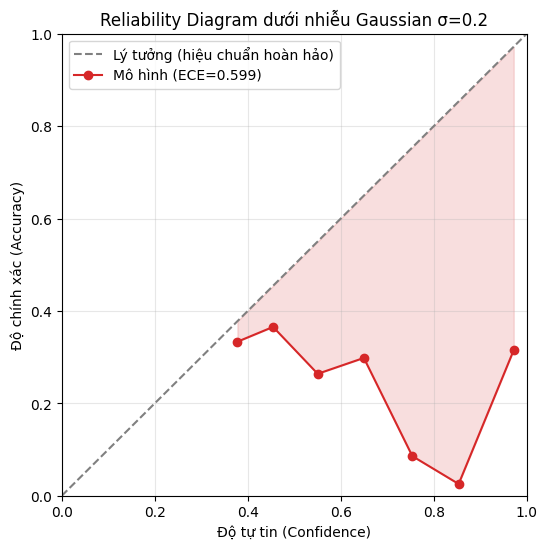

In [54]:
import numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt, os
os.makedirs("figs", exist_ok=True)

@torch.no_grad()
def collect_corrupt(kind="gauss_noise", sev=0.2):
    model.eval(); confs=[]; corrs=[]
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        p = F.softmax(model(corrupt(images, kind, sev)), dim=1)
        conf, pred = p.max(1)
        confs.extend(conf.cpu().numpy()); corrs.extend((pred==labels).cpu().numpy())
    return np.array(confs), np.array(corrs).astype(float)

conf, corr = collect_corrupt()

n_bins = 10
bins = np.linspace(0, 1, n_bins+1)
xs, ys, ws = [], [], []
for i in range(n_bins):
    m = (conf > bins[i]) & (conf <= bins[i+1])
    if m.sum() == 0:
        continue
    xs.append(conf[m].mean()); ys.append(corr[m].mean()); ws.append(m.mean())

ece = sum(w*abs(y-x) for x, y, w in zip(xs, ys, ws))

plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], "--", color="gray", label="Lý tưởng (hiệu chuẩn hoàn hảo)")
plt.plot(xs, ys, marker="o", color="C3", label=f"Mô hình (ECE={ece:.3f})")
plt.fill_between(xs, ys, xs, alpha=0.15, color="C3")
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("Độ tự tin (Confidence)"); plt.ylabel("Độ chính xác (Accuracy)")
plt.title("Reliability Diagram dưới nhiễu Gaussian σ=0.2")
plt.legend(loc="upper left"); plt.grid(alpha=.3)
plt.savefig("figs/reliability_noise.png", dpi=150, bbox_inches="tight")
plt.show()